/tmp/ipykernel_2582/726458438.py:52: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_me

Dropped 0.4% entries from factor data: 0.4% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-17722.837891,-0.034479,-108.110104,1156.151200,18683,20.740913
2,-1.283435,-0.028642,-0.160996,0.113407,17681,19.628544
3,-0.192154,-0.013184,-0.057122,0.028592,17475,19.399853
4,-0.089476,0.000019,-0.019711,0.011947,17681,19.628544
5,-0.029859,1.000000,0.029370,0.087976,18558,20.602145


Returns Analysis


,1D,5D,10D
Ann. alpha,0.101,0.141,0.117
beta,-0.037,-0.047,-0.041
Mean Period Wise Return Top Quantile (bps),4.908,4.294,4.974
Mean Period Wise Return Bottom Quantile (bps),-6.382,-6.480,-6.013
Mean Period Wise Spread (bps),11.290,10.915,11.144


<Figure size 640x480 with 0 Axes>

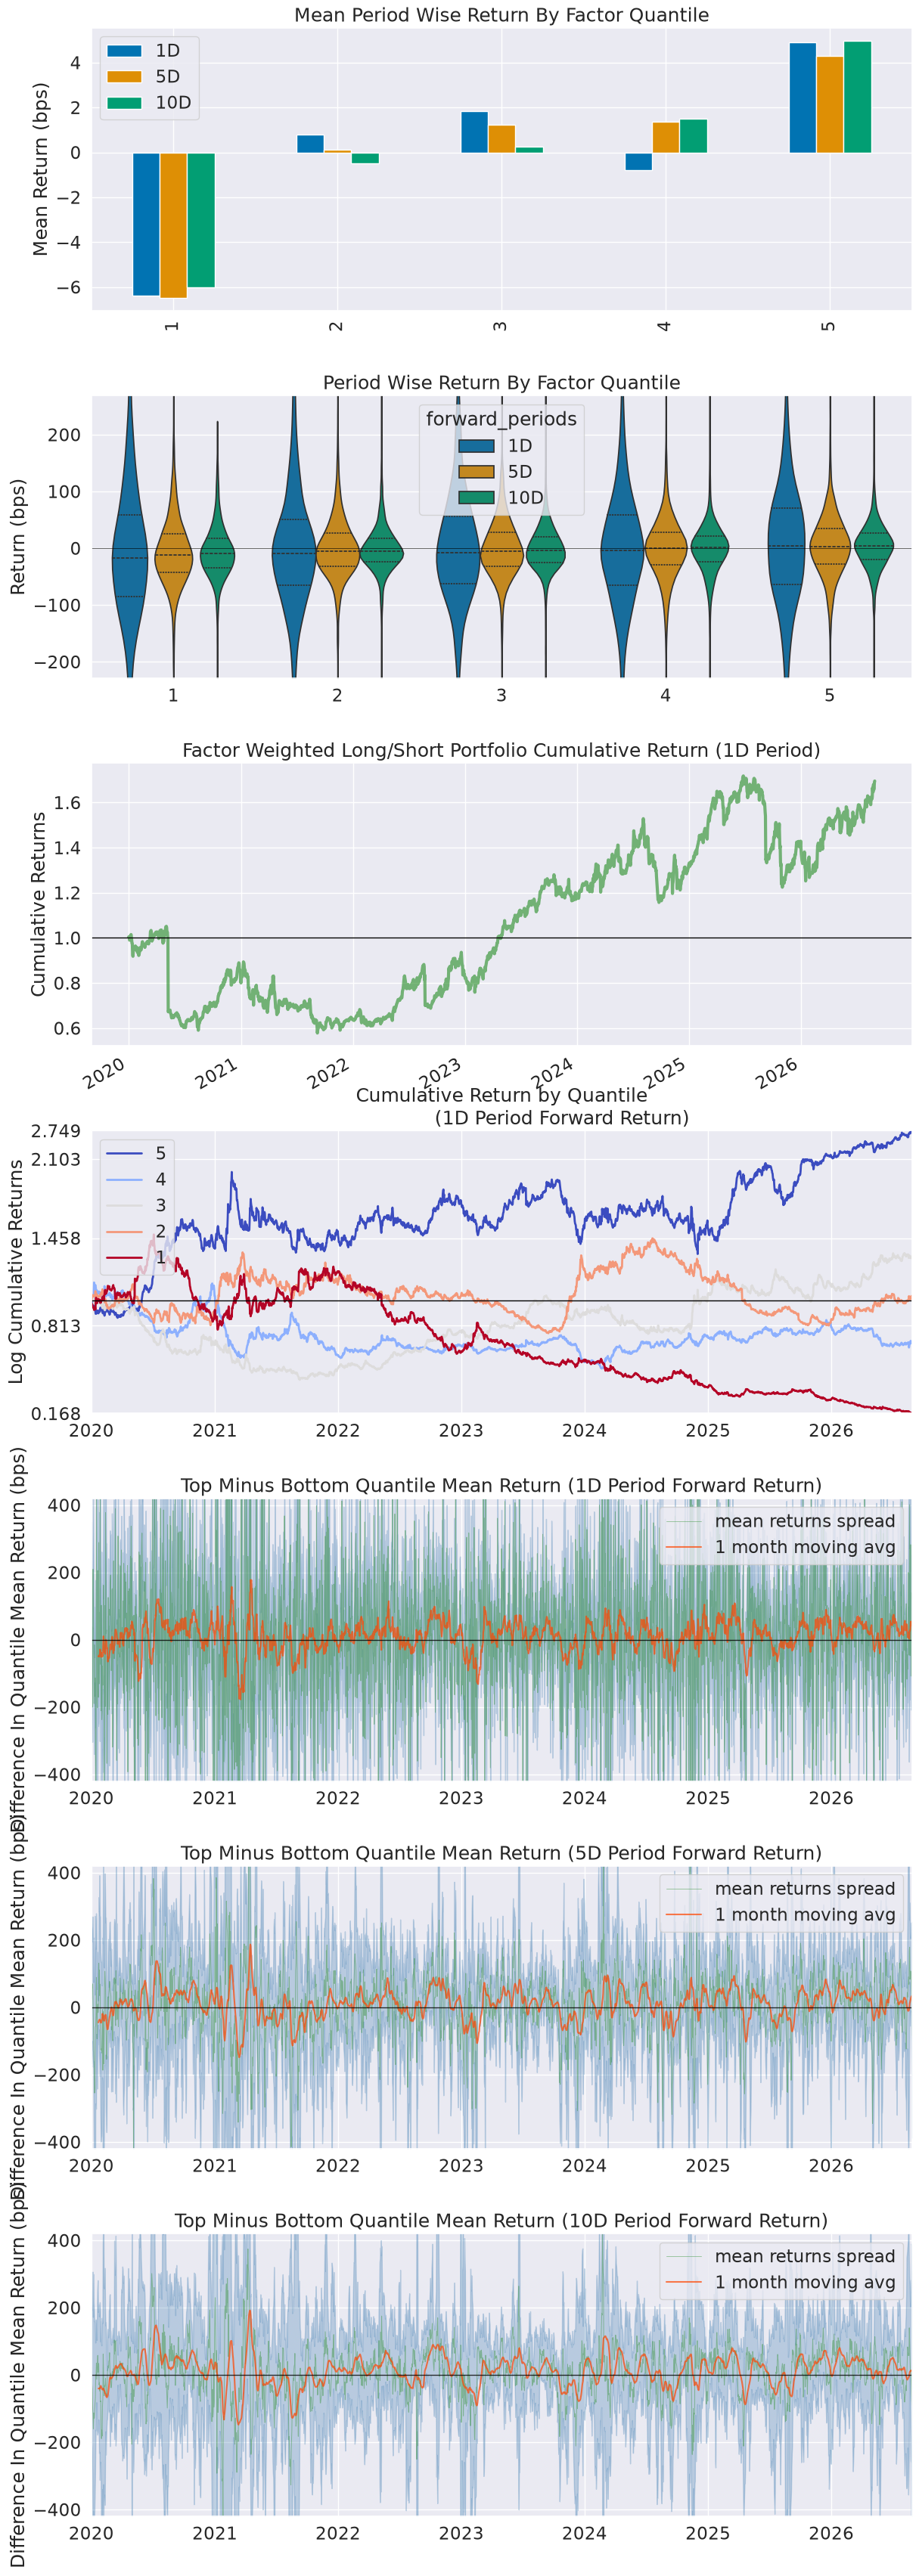

Information Analysis


,1D,5D,10D
IC Mean,0.040,0.062,0.077
IC Std.,0.228,0.234,0.238
Risk-Adjusted IC,0.174,0.266,0.323
t-stat(IC),8.564,13.098,15.947
p-value(IC),0.000,0.000,0.000
IC Skew,-0.042,-0.084,-0.102
IC Kurtosis,-0.536,-0.398,-0.451


/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/alphalens/performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


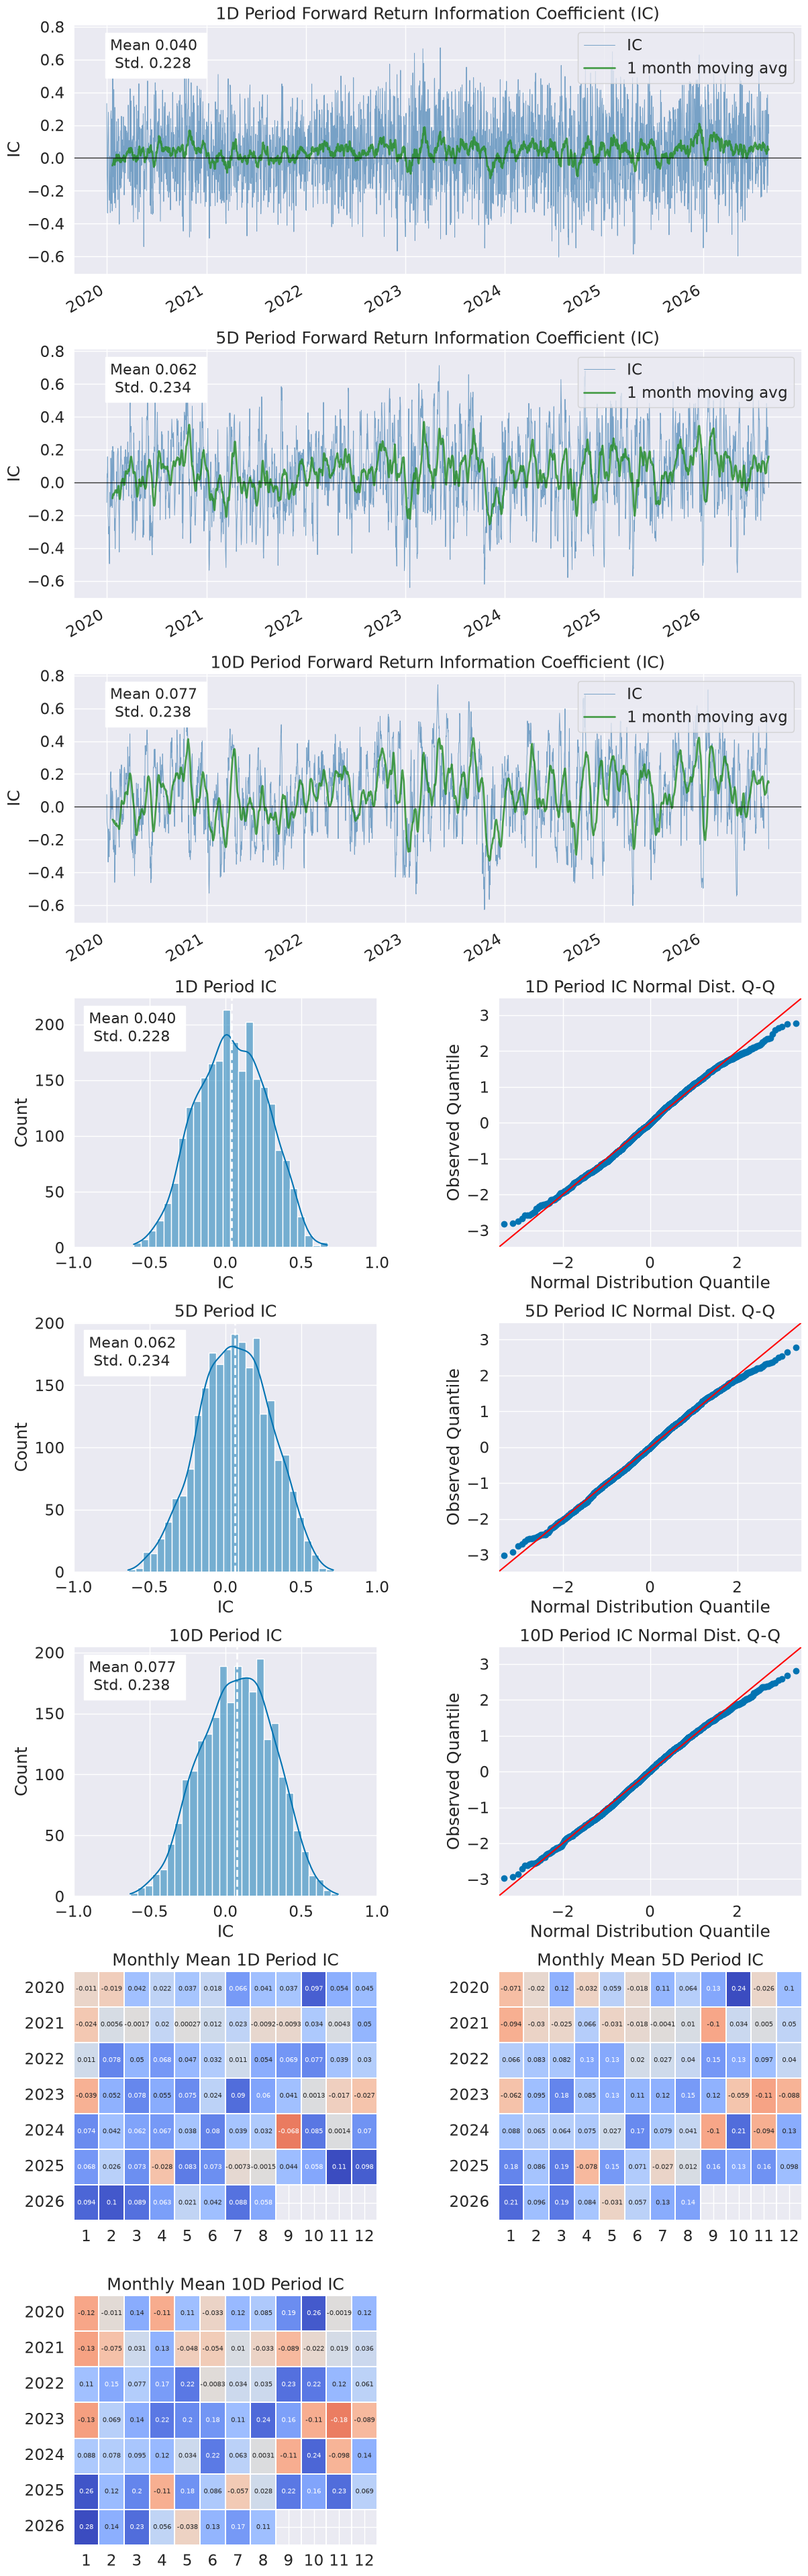

/opt/hostedtoolcache/Python/3.12.14/x64/lib/python3.12/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.052,0.129,0.184
Quantile 2 Mean Turnover,0.074,0.167,0.231
Quantile 3 Mean Turnover,0.070,0.158,0.219
Quantile 4 Mean Turnover,0.068,0.140,0.190
Quantile 5 Mean Turnover,0.048,0.106,0.152


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.996,0.988,0.979


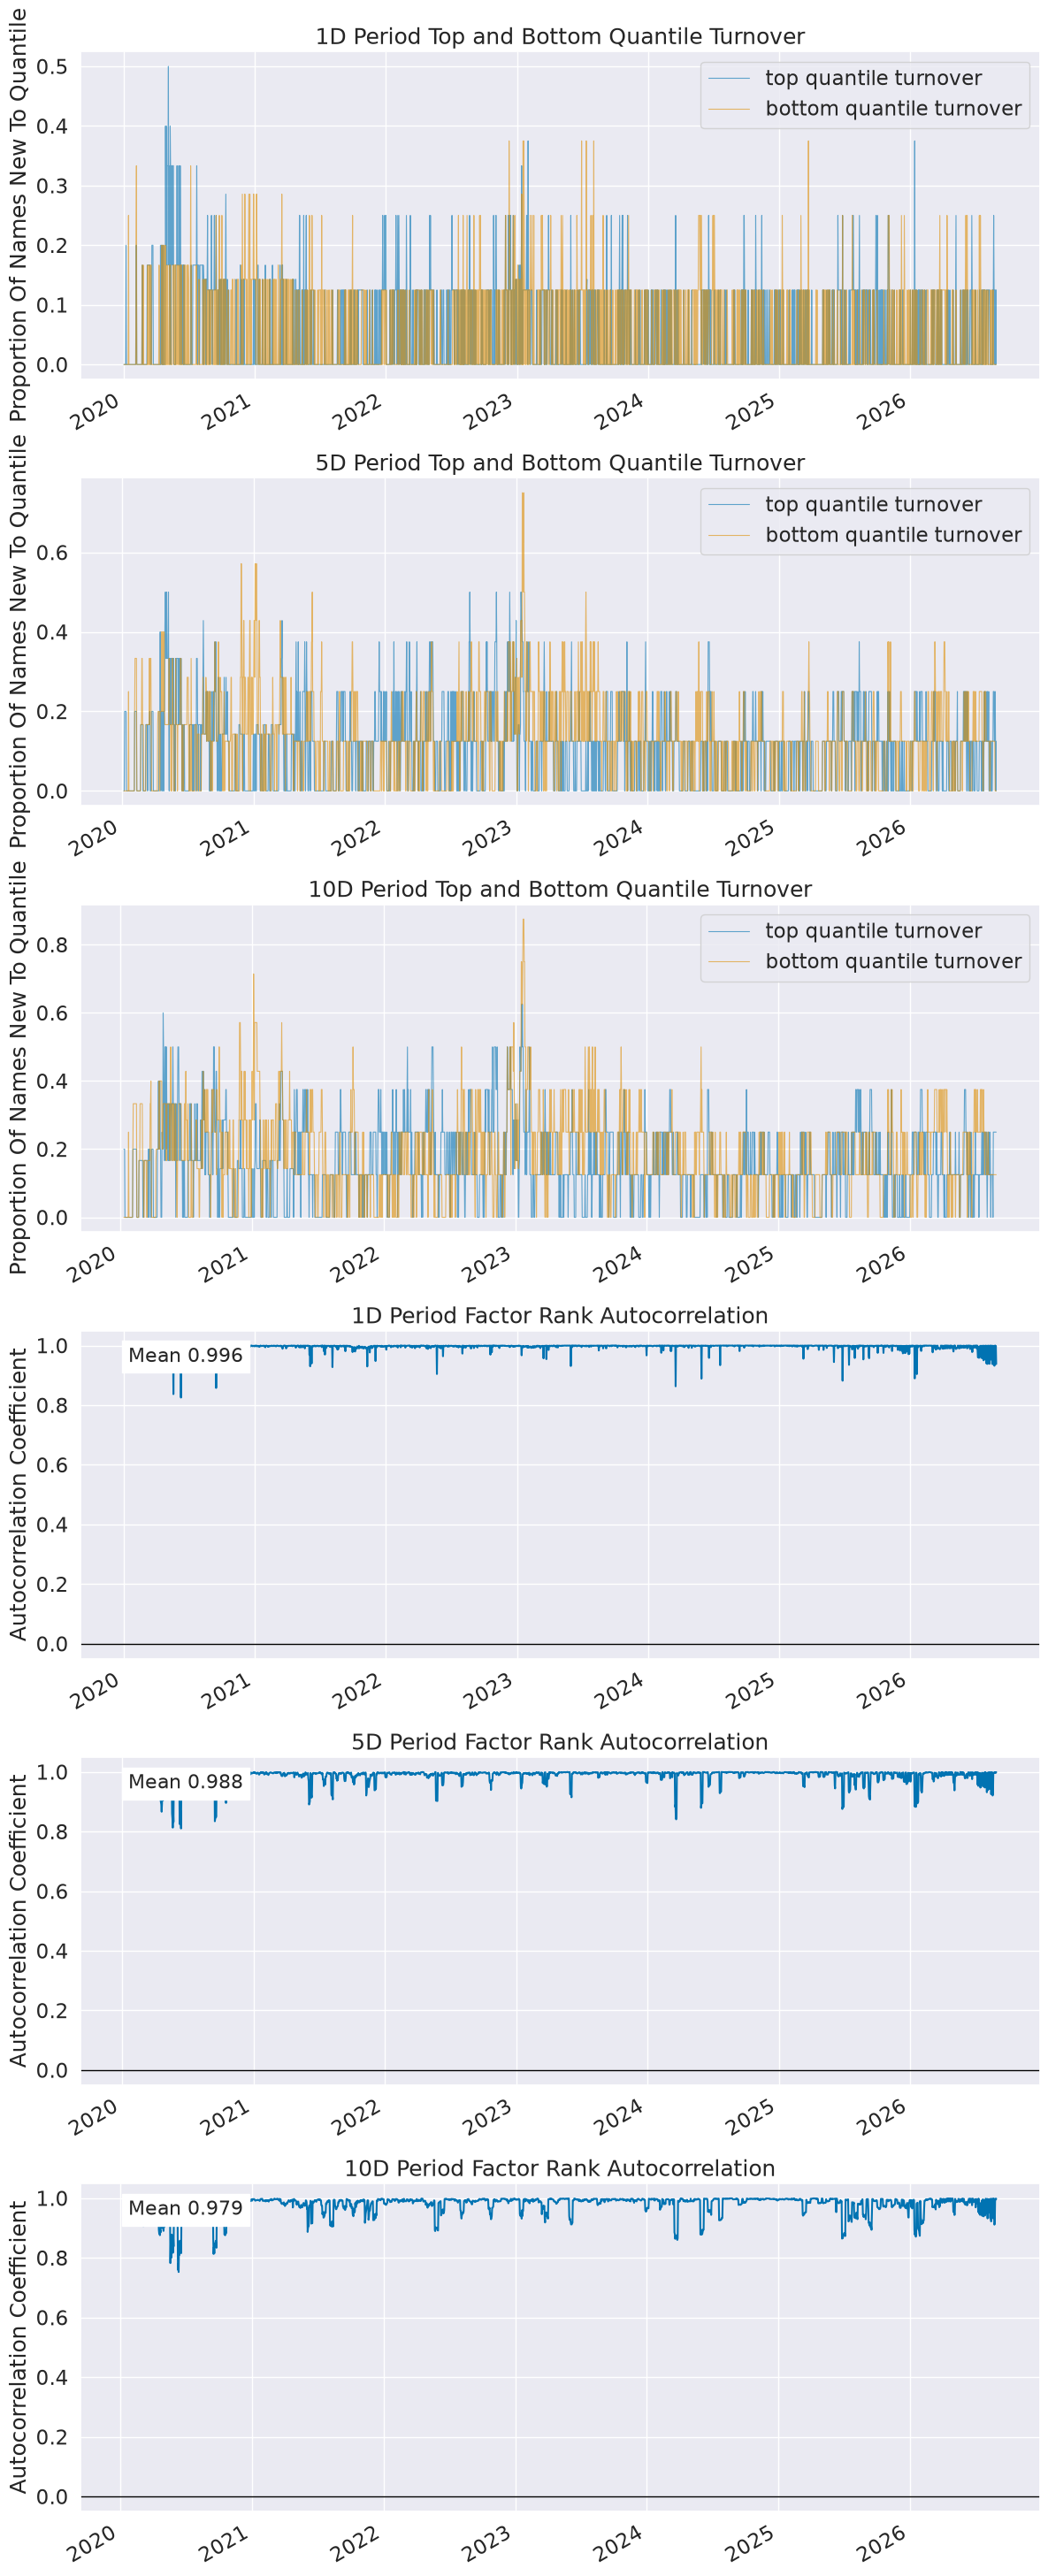

In [1]:
# AUTO-GENERATED from scripts/factors_catalog.py by
# scripts/generate_factor_notebooks.py -- do not edit by hand.
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "notebooks" / "analysis").is_dir() and _root != _root.parent:
    _root = _root.parent
for _p in (_root, _root / "notebooks"):
    sys.path.insert(0, str(_p))

from unravel_client import (
    get_historical_universe,
    get_portfolio_factors_historical,
    get_prices,
    get_tickers,
)

from analysis.alphalens import factor_analysis
from analysis.utils import get_env

UNRAVEL_API_KEY = get_env("UNRAVEL_API_KEY")

# Supply Velocity -- portfolio supply_velocity.40
portfolio = "supply_velocity"
universe_size = "40"

available_tickers = get_tickers(
    id=portfolio,
    api_key=UNRAVEL_API_KEY,
    universe_size=universe_size,
    exchange=None,
)
historical_factors = get_portfolio_factors_historical(
    id=portfolio, tickers=available_tickers, api_key=UNRAVEL_API_KEY
)
underlying = get_prices(tickers=available_tickers, api_key=UNRAVEL_API_KEY)

# Mask the raw factor with the dynamic point-in-time universe (a boolean
# dates x tickers matrix) so AlphaLens scores only the universe we trade,
# not every ticker that was ever tradeable.
universe = get_historical_universe(
    size=universe_size,
    api_key=UNRAVEL_API_KEY,
    start_date=str(historical_factors.index.min().date()),
    end_date=str(historical_factors.index.max().date()),
)
membership = (
    universe.reindex(index=historical_factors.index)
    .ffill()
    .reindex(columns=historical_factors.columns)
    .fillna(False)
    .astype(bool)
)
restricted_factors = historical_factors.where(membership)

columns_intersection = restricted_factors.columns.intersection(underlying.columns)
factor_analysis(restricted_factors[columns_intersection], underlying)